In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('C:/Users/Luqna Aziziyah/Documents/luqna/kuliah/sems 7/DL/CODE/archive'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

C:\Users\Luqna Aziziyah\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\Luqna Aziziyah\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
import math
import cv2
import numpy as np
from time import time
import mediapipe as mp
import matplotlib.pyplot as plt

mp_pose = mp.solutions.pose
pose = mp_pose.Pose(static_image_mode = True, min_detection_confidence=0.3, model_complexity=2)
mp_drawing = mp.solutions.drawing_utils

In [3]:
sample_img = cv2.imread('C:/Users/Luqna Aziziyah/Documents/luqna/kuliah/MASA KULIAH/sems 7/DL/CODE/archive/PoseEstimation/PE/2.jpg')
# plt.figure(figsize=(10,10))
# plt.title('Sample Image');plt.axis('off');plt.imshow(sample_img[:,:,::-1]);plt.show()

In [4]:
results = pose.process(cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB))

# if results.pose_landmarks:
#   for i in range(0,32):
#     print(f'{mp_pose.PoseLandmark(i).name}:\n{results.pose_landmarks.landmark[mp_pose.PoseLandmark(i).value]}')

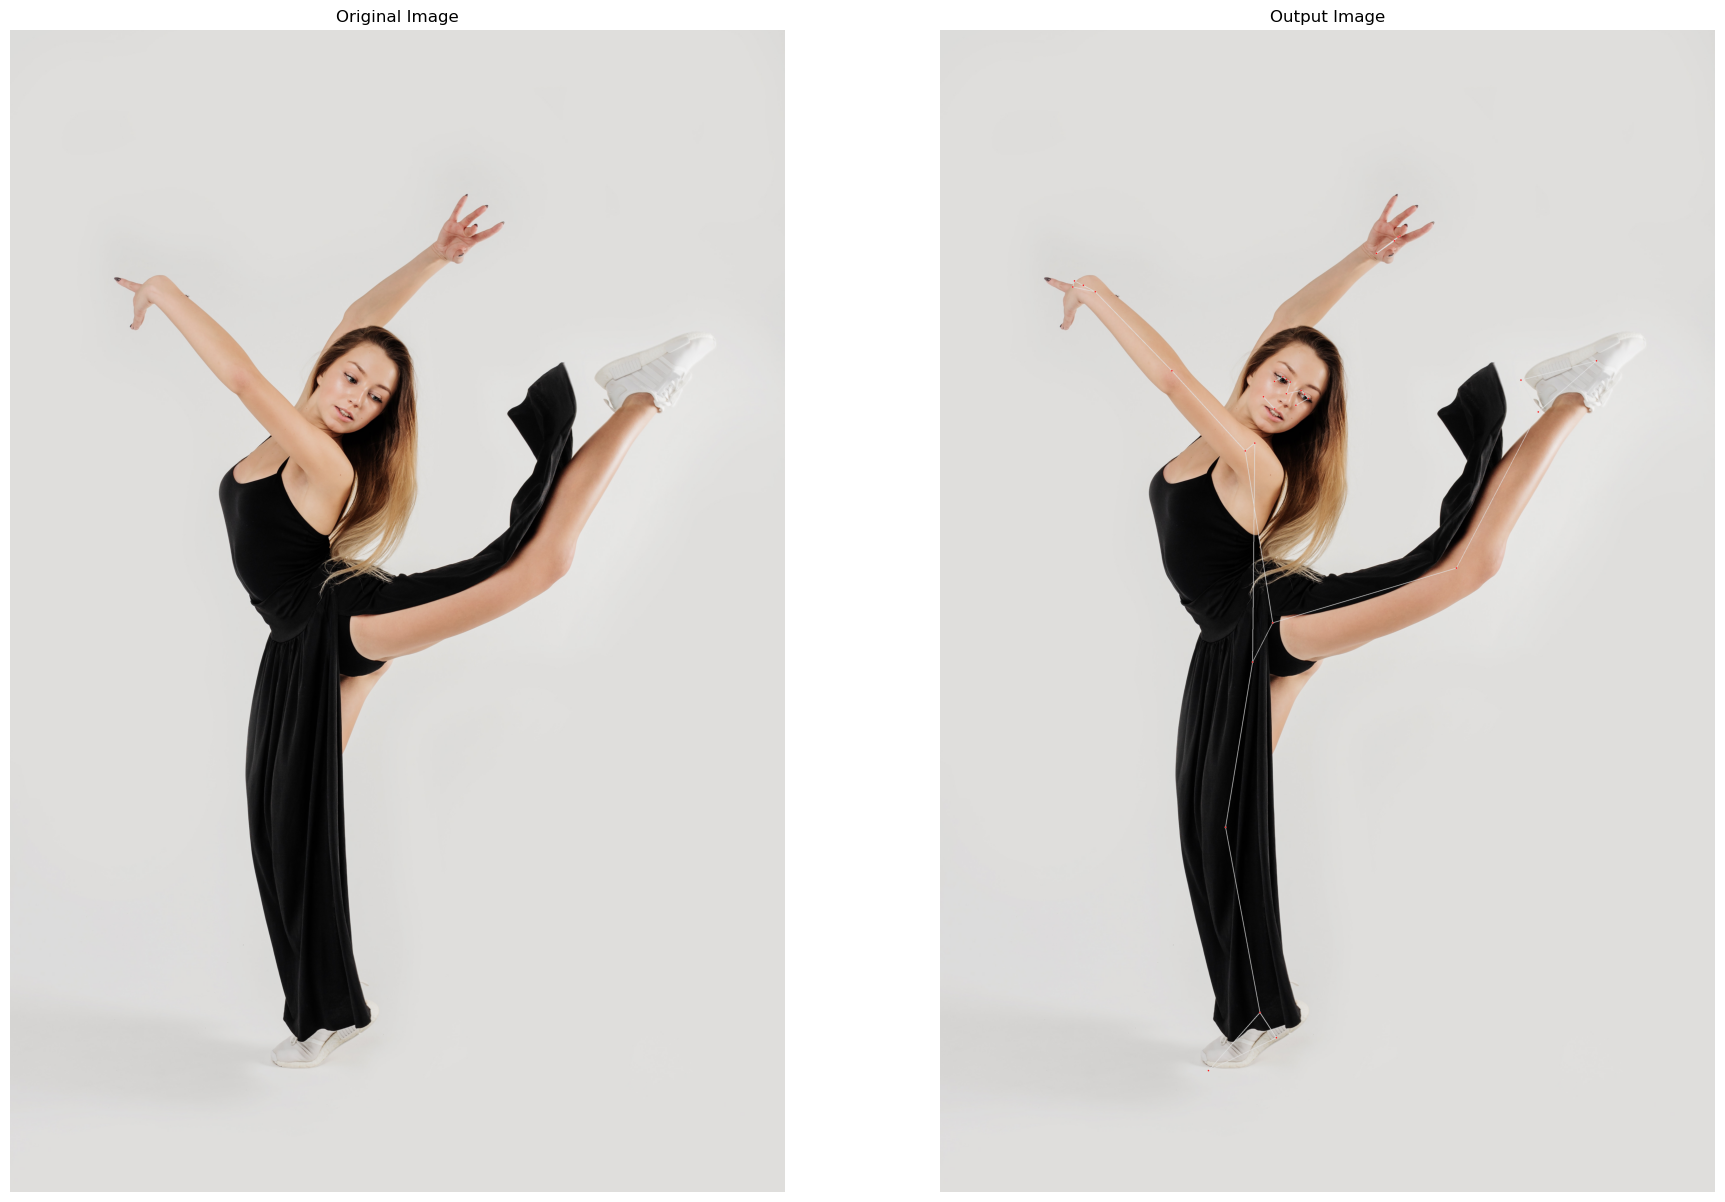

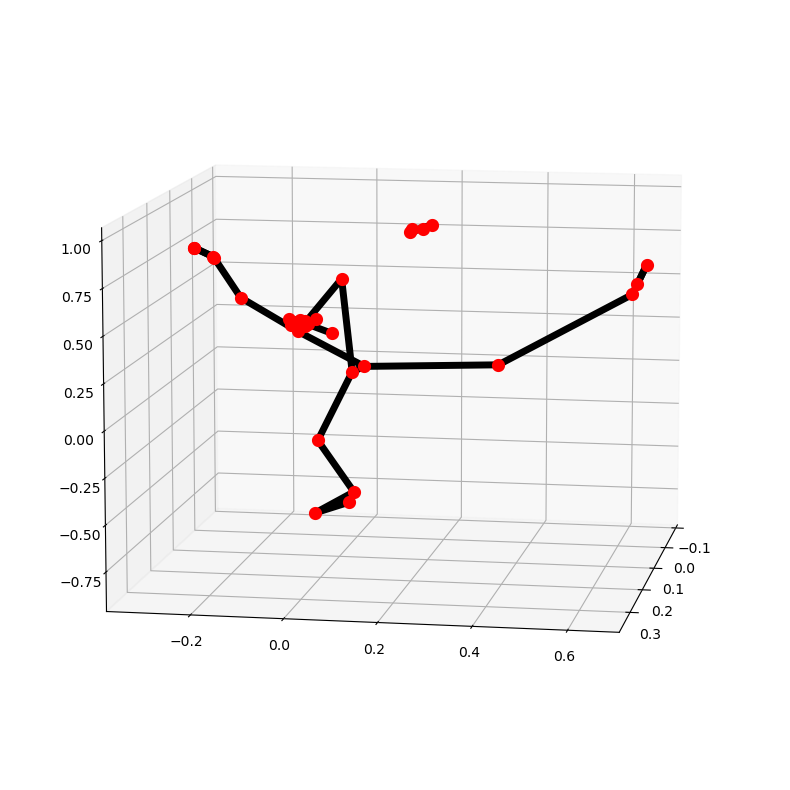

In [5]:
def detect_pose(image,pose,display=True):

  output_image=image.copy()
  imageRGB=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
  results=pose.process(imageRGB)
  height,width, _ = image.shape
  landmarks = []
  if results.pose_landmarks:
    mp_drawing.draw_landmarks(image=output_image,
                              landmark_list=results.pose_landmarks,
                              connections=mp_pose.POSE_CONNECTIONS)

    for landmark in results.pose_landmarks.landmark:
      landmarks.append((int(landmark.x * width),int(landmark.y * height),
                       (landmark.z * width)))

    if display:
        plt.figure(figsize=[22,22])

        plt.subplot(121)
        plt.imshow(image[:,:,::-1])
        plt.title('Original Image')
        plt.axis('off')

        plt.subplot(122)
        plt.imshow(output_image[:,:,::-1])
        plt.title('Output Image')
        plt.axis('off')

        mp_drawing.plot_landmarks(results.pose_world_landmarks,mp_pose.POSE_CONNECTIONS)

    else:
        return output_image,landmarks
    
image = cv2.imread('C:/Users/Luqna Aziziyah/Documents/luqna/kuliah/MASA KULIAH/sems 7/DL/CODE/archive/PoseEstimation/PE/3.jpg')
detect_pose(image, pose,display=True)

In [6]:
import cv2
import mediapipe as mp
import pandas as pd
from matplotlib import pyplot as plt

# Inisialisasi pose dari MediaPipe
mp_pose = mp.solutions.pose
pose = mp_pose.Pose()

# List untuk menyimpan semua data
landmark_data = []

# Iterasi melalui gambar 20 hingga 25
for i in range(0, 28):
    # Path file gambar
    file_path = f'C:/Users/Luqna Aziziyah/Documents/luqna/kuliah/MASA KULIAH/sems 7/DL/CODE/archive/PoseEstimation/PE/{i}.jpg'
    
    # Baca gambar
    sample_img = cv2.imread(file_path)
    
    if sample_img is None:
        print(f"Gambar {i}.jpg tidak ditemukan, melewati...")
        continue
    
    # Tampilkan gambar
    # plt.figure(figsize=(10, 10))
    # plt.title(f'Sample Image {i}'); plt.axis('off')
    # plt.imshow(sample_img[:, :, ::-1])  # Konversi BGR ke RGB untuk matplotlib
    # plt.show()
    
    # Proses gambar dengan MediaPipe
    results = pose.process(cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB))
    
    # Jika landmarks ditemukan
    if results.pose_landmarks:
        for idx, landmark in enumerate(results.pose_landmarks.landmark):
            # Simpan data dalam bentuk dictionary
            landmark_data.append({
                'image_id': i,
                'landmark': mp_pose.PoseLandmark(idx).name,
                'x': landmark.x,
                'y': landmark.y,
                'z': landmark.z,
                'visibility': landmark.visibility
            })
    else:
        print(f"Tidak ada landmarks yang terdeteksi untuk gambar {i}.jpg")

# Simpan data ke dalam DataFrame pandas
df = pd.DataFrame(landmark_data)

# Simpan DataFrame ke CSV
csv_output_path = 'pose_landmarks.csv'
df.to_csv(csv_output_path, index=False)

print(f"Data landmark telah disimpan ke {csv_output_path}")


Tidak ada landmarks yang terdeteksi untuk gambar 22.jpg
Data landmark telah disimpan ke pose_landmarks.csv


In [7]:
df

,image_id,landmark,x,y,z,visibility
0,0,NOSE,0.395406,0.227517,-0.708563,0.999985
1,0,LEFT_EYE_INNER,0.403292,0.216289,-0.680360,0.999969
2,0,LEFT_EYE,0.409044,0.215908,-0.680311,0.999967
3,0,LEFT_EYE_OUTER,0.414695,0.215643,-0.680585,0.999964
4,0,RIGHT_EYE_INNER,0.382498,0.217218,-0.679440,0.999965
...,...,...,...,...,...,...
886,27,RIGHT_ANKLE,0.453365,0.760305,0.093919,0.689202
887,27,LEFT_HEEL,0.713200,0.543703,0.028909,0.673685
888,27,RIGHT_HEEL,0.469508,0.807264,0.102781,0.691739
889,27,LEFT_FOOT_INDEX,0.746676,0.537905,-0.066986,0.664878


In [8]:
# Contoh label (image_id: pose_label)
pose_labels = {
    0: 'ballet',
    1: 'standing',
    2: 'ballet',
    3: 'ballet',
    4: 'squat',
    5: 'running',
    6: 'running',
    7: 'ballet',
    8: 'swimming',
    9: 'swimming',
    10: 'swimming',
    11: 'ballet',
    12: 'ballet',
    13: 'running',
    14: 'sleep',
    15: 'dance',
    16: 'playing basket',
    17: 'running',
    18: 'jump',
    19: 'jump',
    20: 'upside down',
    21 : 'jump',
    23: 'dance',
    24: 'ballet',
    25: 'running',
    26: 'ballet',
    27: 'ballet',
    28: 'squat'
}

# Tambahkan label ke dataframe
df['pose_label'] = df['image_id'].map(pose_labels)


In [9]:
# Pivot tabel: 1 baris per gambar, 1 kolom per koordinat (x, y, z) tiap landmark
pivot_df = df.pivot_table(index='image_id', 
                          columns='landmark', 
                          values=['x', 'y', 'z'])

# Gabungkan multi-index kolom
pivot_df.columns = ['_'.join(col).lower() for col in pivot_df.columns]

# Tambahkan label
pivot_df['pose_label'] = df.groupby('image_id')['pose_label'].first()


In [10]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Label encoding
le = LabelEncoder()
y = le.fit_transform(pivot_df['pose_label'])
y_cat = to_categorical(y)

# Fitur
X = pivot_df.drop(columns=['pose_label']).values
X = X.reshape(X.shape[0], X.shape[1], 1)  # reshape ke [samples, timesteps, channels]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.2, random_state=42)


In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    
    Conv1D(128, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dense(y_cat.shape[1], activation='softmax')  # output sesuai jumlah kelas
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 97, 64)            256       
                                                                 
 max_pooling1d (MaxPooling1D  (None, 48, 64)           0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 48, 64)            0         
                                                                 
 conv1d_1 (Conv1D)           (None, 46, 128)           24704     
                                                                 
 max_pooling1d_1 (MaxPooling  (None, 23, 128)          0         
 1D)                                                             
                                                                 
 dropout_1 (Dropout)         (None, 23, 128)           0

In [12]:
history = model.fit(X_train, y_train, epochs=50, batch_size=8,
                    validation_data=(X_test, y_test))


Epoch 1/50
3/3 [==============================] - 1s 88ms/step - loss: 2.3425 - accuracy: 0.1905 - val_loss: 2.1600 - val_accuracy: 0.3333
Epoch 2/50
3/3 [==============================] - 0s 18ms/step - loss: 2.1082 - accuracy: 0.3333 - val_loss: 2.1480 - val_accuracy: 0.3333
Epoch 3/50
3/3 [==============================] - 0s 18ms/step - loss: 2.0525 - accuracy: 0.3333 - val_loss: 2.1224 - val_accuracy: 0.3333
Epoch 4/50
3/3 [==============================] - 0s 17ms/step - loss: 1.9765 - accuracy: 0.3333 - val_loss: 2.1190 - val_accuracy: 0.3333
Epoch 5/50
3/3 [==============================] - 0s 23ms/step - loss: 1.9128 - accuracy: 0.4286 - val_loss: 2.0689 - val_accuracy: 0.3333
Epoch 6/50
3/3 [==============================] - 0s 17ms/step - loss: 1.8453 - accuracy: 0.3810 - val_loss: 2.0451 - val_accuracy: 0.3333
Epoch 7/50
3/3 [==============================] - 0s 18ms/step - loss: 1.7584 - accuracy: 0.4286 - val_loss: 2.0337 - val_accuracy: 0.3333
Epoch 8/50
3/3 [===========

In [13]:
from sklearn.metrics import classification_report
loss, acc = model.evaluate(X_test, y_test)
print(f'Akurasi: {acc:.2f}')

# Prediksi
y_pred = model.predict(X_test)
y_pred_label = np.argmax(y_pred, axis=1)
y_true_label = np.argmax(y_test, axis=1)

print(classification_report(
    y_true_label, 
    y_pred_label, 
    target_names=le.classes_,
    labels=range(len(le.classes_))
))


1/1 [==============================] - 0s 19ms/step - loss: 8.2067 - accuracy: 0.3333
Akurasi: 0.33
1/1 [==============================] - 0s 80ms/step
                precision    recall  f1-score   support

        ballet       0.50      0.50      0.50         2
         dance       0.00      0.00      0.00         0
          jump       0.00      0.00      0.00         1
playing basket       0.00      0.00      0.00         0
       running       0.00      0.00      0.00         1
         sleep       0.00      0.00      0.00         0
         squat       0.00      0.00      0.00         0
      standing       0.00      0.00      0.00         0
      swimming       1.00      0.50      0.67         2
   upside down       0.00      0.00      0.00         0

      accuracy                           0.33         6
     macro avg       0.15      0.10      0.12         6
  weighted avg       0.50      0.33      0.39         6



C:\Users\Luqna Aziziyah\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Luqna Aziziyah\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Luqna Aziziyah\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Luqna

In [14]:
# Pisahkan fitur dan target
X = pivot_df.drop(columns=['pose_label'])
y = pivot_df['pose_label']

# Encode label
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [15]:
from sklearn.ensemble import RandomForestClassifier
# Split data menjadi train dan test set
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [16]:
# Prediksi pada data test
y_pred = rf_model.predict(X_test)

# Laporan evaluasi
print(classification_report(
    y_test, 
    y_pred, 
    target_names=le.classes_,
    labels=range(len(le.classes_))
))

                precision    recall  f1-score   support

        ballet       0.50      1.00      0.67         2
         dance       0.00      0.00      0.00         0
          jump       0.00      0.00      0.00         1
playing basket       0.00      0.00      0.00         0
       running       0.00      0.00      0.00         1
         sleep       0.00      0.00      0.00         0
         squat       0.00      0.00      0.00         0
      standing       0.00      0.00      0.00         0
      swimming       1.00      0.50      0.67         2
   upside down       0.00      0.00      0.00         0

      accuracy                           0.50         6
     macro avg       0.15      0.15      0.13         6
  weighted avg       0.50      0.50      0.44         6



C:\Users\Luqna Aziziyah\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Luqna Aziziyah\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Luqna Aziziyah\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Luqna

Accuracy = Berapa banyak prediksi yang benar dari seluruh data.

Macro avg = Rata-rata dari precision/recall/F1 semua kelas tanpa melihat jumlah data tiap kelas (jadi adil untuk kelas minoritas).

Weighted avg = Sama seperti macro, tapi mempertimbangkan jumlah data tiap kelas.

Extracted features count: 132
Random Forest expected features: 99
1/1 [==============================] - 0s 17ms/step


C:\Users\Luqna Aziziyah\anaconda3\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Luqna Aziziyah\anaconda3\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


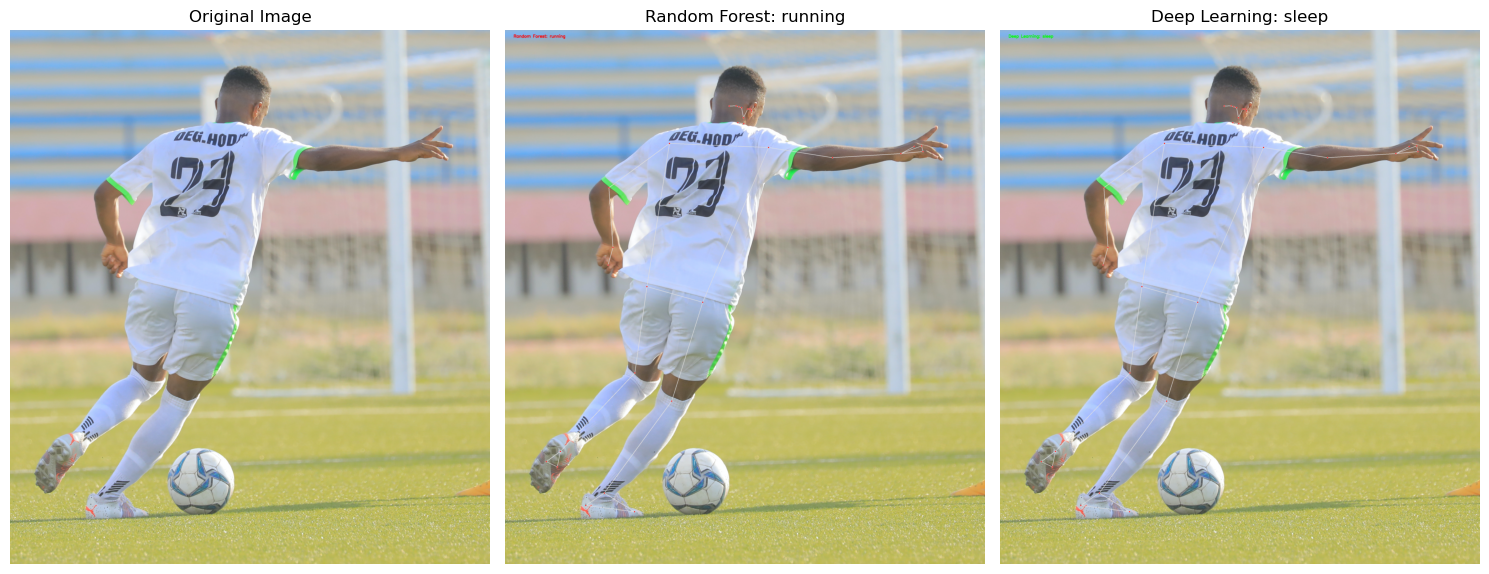


--- MODEL COMPARISON ---

Random Forest Confidence:
ballet: 0.1800
dance: 0.0300
jump: 0.1400
playing basket: 0.0300
running: 0.3300
sleep: 0.1000
squat: 0.0600
standing: 0.0400
swimming: 0.0300
upside down: 0.0600

Deep Learning Confidence:
ballet: 0.0067
dance: 0.0009
jump: 0.0042
playing basket: 0.0000
running: 0.1118
sleep: 0.8764
squat: 0.0000
standing: 0.0000
swimming: 0.0000
upside down: 0.0000

Prediction Match: ✗
Random Forest: running
Deep Learning: sleep


In [19]:
import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import pandas as pd

# Debug information about feature counts
def print_feature_info(landmarks):
    """Print information about extracted landmarks"""
    landmarks_flat = np.array(landmarks).flatten()
    print(f"Extracted features count: {landmarks_flat.shape[0]}")
    return landmarks_flat.shape[0]

# Assuming pivot_df, model training, and other prerequisites are already done
# For demonstration, I'll include the code but comment it out

'''
# Preprocessing and model training steps
# Pisahkan fitur dan target
X = pivot_df.drop(columns=['pose_label'])
y = pivot_df['pose_label']

# Encode label
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split data menjadi train dan test set
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Prediksi pada data test
y_pred = rf_model.predict(X_test)

# Laporan evaluasi
print(classification_report(
    y_test, 
    y_pred, 
    target_names=le.classes_,
    labels=range(len(le.classes_))
))
'''

# Function to preprocess landmarks for Random Forest model
def preprocess_for_rf(landmarks, num_features):
    """Convert landmarks to format expected by Random Forest model"""
    landmarks_flat = np.array(landmarks).flatten()
    
    # Handle feature count mismatch
    if landmarks_flat.shape[0] != num_features:
        print(f"Warning: Feature count mismatch. Expected {num_features}, got {landmarks_flat.shape[0]}")
        if landmarks_flat.shape[0] > num_features:
            # Truncate if we have too many features
            landmarks_flat = landmarks_flat[:num_features]
        else:
            # Pad with zeros if we have too few features
            padding = np.zeros(num_features - landmarks_flat.shape[0])
            landmarks_flat = np.concatenate([landmarks_flat, padding])
    
    return landmarks_flat.reshape(1, -1)  # Reshape for single sample prediction

# Function to preprocess landmarks for Deep Learning model
def preprocess_for_dl(landmarks, num_features):
    """Convert landmarks to format expected by Deep Learning model"""
    landmarks_flat = np.array(landmarks).flatten()
    
    # Adjust feature count if needed
    if landmarks_flat.shape[0] != num_features:
        if landmarks_flat.shape[0] > num_features:
            landmarks_flat = landmarks_flat[:num_features]
        else:
            padding = np.zeros(num_features - landmarks_flat.shape[0])
            landmarks_flat = np.concatenate([landmarks_flat, padding])
    
    return landmarks_flat.reshape(1, num_features, 1)  # Reshape for DL model input

# Main prediction function
def predict_pose(img_path, rf_model, dl_model, le):
    # Inisialisasi pose dari MediaPipe
    mp_pose = mp.solutions.pose
    pose = mp_pose.Pose()
    
    # Load image
    img = cv2.imread(img_path)
    if img is None:
        print(f"Error: Tidak dapat membaca gambar dari {img_path}")
        return
        
    # Process image with MediaPipe
    results = pose.process(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    
    # If landmarks detected
    if results.pose_landmarks:
        annotated_image = img.copy()
        mp.solutions.drawing_utils.draw_landmarks(annotated_image, results.pose_landmarks, mp_pose.POSE_CONNECTIONS)
        
        # Extract landmarks
        landmarks = []
        for landmark in results.pose_landmarks.landmark:
            landmarks.append([landmark.x, landmark.y, landmark.z, landmark.visibility])
        
        # Print debug information about features
        print_feature_info(landmarks)
        print(f"Random Forest expected features: {rf_model.n_features_in_}")
        
        # Prepare inputs for both models
        rf_input = preprocess_for_rf(landmarks, rf_model.n_features_in_)  # Use model's expected feature count
        dl_input = preprocess_for_dl(landmarks, X_train.shape[1])  # Assuming X_train is available
        
        # Make predictions
        rf_pred_class = rf_model.predict(rf_input)[0]
        rf_pose_label = le.inverse_transform([rf_pred_class])[0]
        rf_proba = rf_model.predict_proba(rf_input)[0]
        
        dl_pred = dl_model.predict(dl_input)
        dl_pred_class = np.argmax(dl_pred)
        dl_pose_label = le.inverse_transform([dl_pred_class])[0]
        
        # Create visualization
        fig = plt.figure(figsize=(15, 10))
        
        # Original image
        plt.subplot(1, 3, 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title('Original Image')
        plt.axis('off')
        
        # Random Forest prediction
        rf_img = annotated_image.copy()
        cv2.putText(rf_img, f'Random Forest: {rf_pose_label}', (50, 50), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2, cv2.LINE_AA)
        plt.subplot(1, 3, 2)
        plt.imshow(cv2.cvtColor(rf_img, cv2.COLOR_BGR2RGB))
        plt.title(f'Random Forest: {rf_pose_label}')
        plt.axis('off')
        
        # Deep Learning prediction
        dl_img = annotated_image.copy()
        cv2.putText(dl_img, f'Deep Learning: {dl_pose_label}', (50, 50), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2, cv2.LINE_AA)
        plt.subplot(1, 3, 3)
        plt.imshow(cv2.cvtColor(dl_img, cv2.COLOR_BGR2RGB))
        plt.title(f'Deep Learning: {dl_pose_label}')
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()
        
        # Print confidence comparison
        print("\n--- MODEL COMPARISON ---")
        print("\nRandom Forest Confidence:")
        for i, (label, confidence) in enumerate(zip(le.classes_, rf_proba)):
            print(f"{label}: {confidence:.4f}")
        
        print("\nDeep Learning Confidence:")
        for i, (label, confidence) in enumerate(zip(le.classes_, dl_pred[0])):
            print(f"{label}: {confidence:.4f}")
        
        # Show if predictions match
        print("\nPrediction Match:", "✓" if rf_pose_label == dl_pose_label else "✗")
        print(f"Random Forest: {rf_pose_label}")
        print(f"Deep Learning: {dl_pose_label}")
    else:
        print("No pose landmarks detected in the image")

# Example usage
# Path gambar
img_path = 'C:/Users/Luqna Aziziyah/Documents/luqna/kuliah/MASA KULIAH/sems 7/DL/CODE/archive/PoseEstimation/PE/25.jpg'

# Call the prediction function
# Assuming rf_model, model (DL model), and le (label encoder) are already defined
predict_pose(img_path, rf_model, model, le)

In [1]:
pwd

'C:\\Users\\Luqna Aziziyah'